In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv("/kaggle/input/autism-screening/Autism_Data.arff",na_values='?')

In [3]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,NaN,no,no,Egypt,no,2,'18 and more',NaN,NO


In [4]:
df.replace("?",np.mean,inplace=True)

In [5]:
df.shape

(704, 21)

In [6]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [7]:
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])
df['ethnicity']=le.fit_transform(df['ethnicity'])
df['jundice']=le.fit_transform(df['jundice'])
df['contry_of_res']=le.fit_transform(df['contry_of_res'])
df['age_desc']=le.fit_transform(df['age_desc'])
df['relation']=le.fit_transform(df['relation'])
df['Class/ASD']=le.fit_transform(df['Class/ASD'])
df['austim']=le.fit_transform(df['austim'])
df['used_app_before']=le.fit_transform(df['used_app_before'])

In [8]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,0,9,0,0,10,0,6,0,4,0
1,1,1,0,1,0,0,0,1,0,1,...,1,5,0,1,25,0,5,0,4,0
2,1,1,0,1,1,0,1,1,1,1,...,1,5,1,1,61,0,8,0,2,1
3,1,1,0,1,0,0,1,1,0,1,...,0,9,0,1,10,0,6,0,4,0
4,1,0,0,0,0,0,0,1,0,0,...,0,11,0,0,32,0,2,0,5,0


In [9]:
df.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                2
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [10]:
df.drop('ethnicity',axis=1,inplace=True)
df.drop('relation',axis=1,inplace=True)

In [11]:
df['age'].fillna(df['age'].mean())

0      26.0
1      24.0
2      27.0
3      35.0
4      40.0
       ... 
699    25.0
700    34.0
701    24.0
702    35.0
703    26.0
Name: age, Length: 704, dtype: float64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    int64  
 1   A2_Score         704 non-null    int64  
 2   A3_Score         704 non-null    int64  
 3   A4_Score         704 non-null    int64  
 4   A5_Score         704 non-null    int64  
 5   A6_Score         704 non-null    int64  
 6   A7_Score         704 non-null    int64  
 7   A8_Score         704 non-null    int64  
 8   A9_Score         704 non-null    int64  
 9   A10_Score        704 non-null    int64  
 10  age              702 non-null    float64
 11  gender           704 non-null    int64  
 12  jundice          704 non-null    int64  
 13  austim           704 non-null    int64  
 14  contry_of_res    704 non-null    int64  
 15  used_app_before  704 non-null    int64  
 16  result           704 non-null    int64  
 17  age_desc        

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
A1_Score,704.0,0.721591,0.448535,0.0,0.0,1.0,1.0,1.0
A2_Score,704.0,0.453125,0.498152,0.0,0.0,0.0,1.0,1.0
A3_Score,704.0,0.457386,0.498535,0.0,0.0,0.0,1.0,1.0
A4_Score,704.0,0.495739,0.500337,0.0,0.0,0.0,1.0,1.0
A5_Score,704.0,0.498580,0.500353,0.0,0.0,0.0,1.0,1.0
A6_Score,704.0,0.284091,0.451301,0.0,0.0,0.0,1.0,1.0
A7_Score,704.0,0.417614,0.493516,0.0,0.0,0.0,1.0,1.0
A8_Score,704.0,0.649148,0.477576,0.0,0.0,1.0,1.0,1.0
A9_Score,704.0,0.323864,0.468281,0.0,0.0,0.0,1.0,1.0
A10_Score,704.0,0.573864,0.494866,0.0,0.0,1.0,1.0,1.0


In [14]:
X=df.drop('Class/ASD',axis=1)
y=df['Class/ASD']

In [15]:
from sklearn.impute import SimpleImputer
impute=SimpleImputer(strategy='mean')
X=impute.fit_transform(X)

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [18]:
from sklearn.neighbors import KNeighborsClassifier

In [19]:
model=KNeighborsClassifier(n_neighbors=6)
model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=6)

In [20]:
model.score(X_train,y_train)

0.9822380106571936

In [21]:
model.score(X_test,y_test)

0.9858156028368794

In [22]:
import pickle

# حفظ
with open('/kaggle/working/model.pkl', 'wb') as f:
    pickle.dump(model, f)

# تحميل
with open('/kaggle/working/model.pkl', 'rb') as f:
    model = pickle.load(f)

In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.9858156028368794
Precision: 0.986562150055991
Recall: 0.9858156028368794
F1 Score: 0.9859390896624939


In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[103   2]
 [  0  36]]


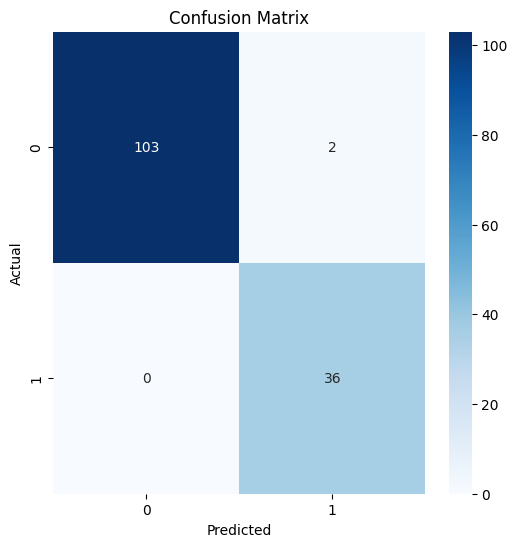

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       105
           1       0.95      1.00      0.97        36

    accuracy                           0.99       141
   macro avg       0.97      0.99      0.98       141
weighted avg       0.99      0.99      0.99       141

